In [87]:
import pandas as pd
import yfinance as yf

# list of benchmark companies - tech companies
tickers = ["MSFT", "AAPL", "GOOGL", "META"]
ratios_dataframe = {}  # storage dictionary

    # Loop directly through the input variable 'tickers'
for ticker in tickers:
    print(f" data retrieval for {ticker}...")
        
    # 1. connection to financial API
    company_data = yf.Ticker(ticker)
    
    # 2. Download of 3 financial statements (historical annual data)
    income_statement = company_data.financials.T
    balance_sheet = company_data.balance_sheet.T
    cash_flow = company_data.cashflow.T
    
    # price retrieval in real time
    current_price = company_data.info.get("currentPrice")
    
    # 4. index cleaning
    income_statement.index = pd.to_datetime(income_statement.index).year
    balance_sheet.index = pd.to_datetime(balance_sheet.index).year
    cash_flow.index = pd.to_datetime(cash_flow.index).year
        
    # 5. Combination of the three statements with "combine_first" method
    merged_df = income_statement.combine_first(balance_sheet)
    full_financials_df = merged_df.combine_first(cash_flow)
    
    # 6. Add two columns corresponding to the current price, and the ticker
    full_financials_df['Current_Price'] = current_price
    full_financials_df['Company'] = ticker
        
    # retrieve the year column to facilitate visualization afterward
    full_financials_df = full_financials_df.reset_index().rename(columns={"index": "Year"})
    
    # we store each company's table in the dictionary before ending the loop
    ratios_dataframe[ticker] = full_financials_df.copy()
    
print("\n gross data are ready.")

 data retrieval for MSFT...
 data retrieval for AAPL...
 data retrieval for GOOGL...
 data retrieval for META...

 gross data are ready.


In [89]:
# FINANCIAL AND OPERATING RATIOS PIPELINE

print("Calculating comprehensive financial metrics across all 4 pillars...")
    
try: 
    for ticker in tickers: 
        df = ratios_dataframe[ticker]
        df = df.sort_values(by="Year", ascending=True).reset_index(drop=True)
            
        # financial pillars calculation
        df["Revenue_Growth_Pct"] = df["Total Revenue"].pct_change() * 100 
        df["Net_Income_Growth_Pct"] = df["Net Income"].pct_change() * 100
        df["Operating_Margin_Pct"] = (df["Operating Income"] / df["Total Revenue"]) * 100
        df["ROE_Pct"] = (df["Net Income"] / df["Stockholders Equity"]) * 100
        df["Current_Ratio"] = df["Current Assets"] / df["Current Liabilities"]
        df["Debt_to_Equity"] = df["Total Debt"] / df["Stockholders Equity"]
        df["Calculated_EPS"] = df["Net Income"] / df["Basic Average Shares"] 
        df["PE_Ratio"] = df["Current_Price"] / df["Calculated_EPS"]
            
        ratios_dataframe[ticker] = df 
            
    print(" All quantitative ratios have been generated.")
except Exception as e:
    print(f" Couldn't do the calculation because: {e}")

Calculating comprehensive financial metrics across all 4 pillars...
 All quantitative ratios have been generated.


In [90]:
# PEERS BENCHMARKING

print("Creating master table and calculating sector benchmarks...")
for ticker, df in ratios_dataframe.items():
    print(ticker, df["Company"].unique())
# 1. Stack all individual company dataframes vertically
# pd.concat takes the dataframes from our dictionary values with the values method and stitches them together and resetting the index with ignore_index
master_table = pd.concat(ratios_dataframe.values(), ignore_index=True)
print(master_table["Company"].value_counts())
# 2. Filter down to only the columns we actually care about for our report
reporting_columns = ["Company", "Year", "Revenue_Growth_Pct", "Net_Income_Growth_Pct", "Operating_Margin_Pct", 
                     "ROE_Pct", "Current_Ratio", "Debt_to_Equity", "PE_Ratio"]
clean_master_table = master_table[reporting_columns]
clean_master_table = clean_master_table[clean_master_table['Year'].isin([2022,2023,2024,2025])]

# 3. Calculate the peer group's average for each year
# We group by "Year" so we don't mix 2023 data with 2024 data.
# We exclude the 'Company' and 'Year' columns because you can't calculate the mathematical average of text strings or dates
numeric_cols = [col for col in reporting_columns if col != "Company" and col != "Year"]
peers_averages = clean_master_table.groupby("Year")[numeric_cols].mean().reset_index()

# Tag this new dataframe so we know it represents the whole sector
peers_averages["Company"] = "PEER_AVG"

# 4. Combine companies and peers averages
# We stack the peers averages right below the company data
final_benchmark_table = pd.concat([clean_master_table, peers_averages], ignore_index=True)

# Sort by Year and Company so it's beautiful and easy to read side-by-side
final_benchmark_table = final_benchmark_table.sort_values(by=["Year", "Company"]).reset_index(drop=True)

print("The peers benchmark table is fully built.")
print("1. Liste des entreprises dans le dictionnaire :", list(ratios_dataframe.keys()))
print(final_benchmark_table)
#TO CHECK THAT ALL TICKERS' DATA HAVE BEEN UPLOADED
for ticker, df in ratios_dataframe.items():
    print("\n", ticker)
    print(df[["Company","Year"]].head())

Creating master table and calculating sector benchmarks...
MSFT ['MSFT']
AAPL ['AAPL']
GOOGL ['GOOGL']
META ['META']
Company
MSFT     5
AAPL     5
GOOGL    5
META     5
Name: count, dtype: int64
The peers benchmark table is fully built.
1. Liste des entreprises dans le dictionnaire : ['MSFT', 'AAPL', 'GOOGL', 'META']
     Company  Year  Revenue_Growth_Pct  Net_Income_Growth_Pct  \
0       AAPL  2022                 NaN                    NaN   
1      GOOGL  2022                 NaN                    NaN   
2       META  2022                 NaN                    NaN   
3       MSFT  2022                 NaN                    NaN   
4   PEER_AVG  2022                 NaN                    NaN   
5       AAPL  2023           -2.800461              -2.813543   
6      GOOGL  2023            8.682770              23.049090   
7       META  2023           15.687468              68.525862   
8       MSFT  2023            6.882030              -0.518299   
9   PEER_AVG  2023            7

 Rendering Financial Peer Dashboard...


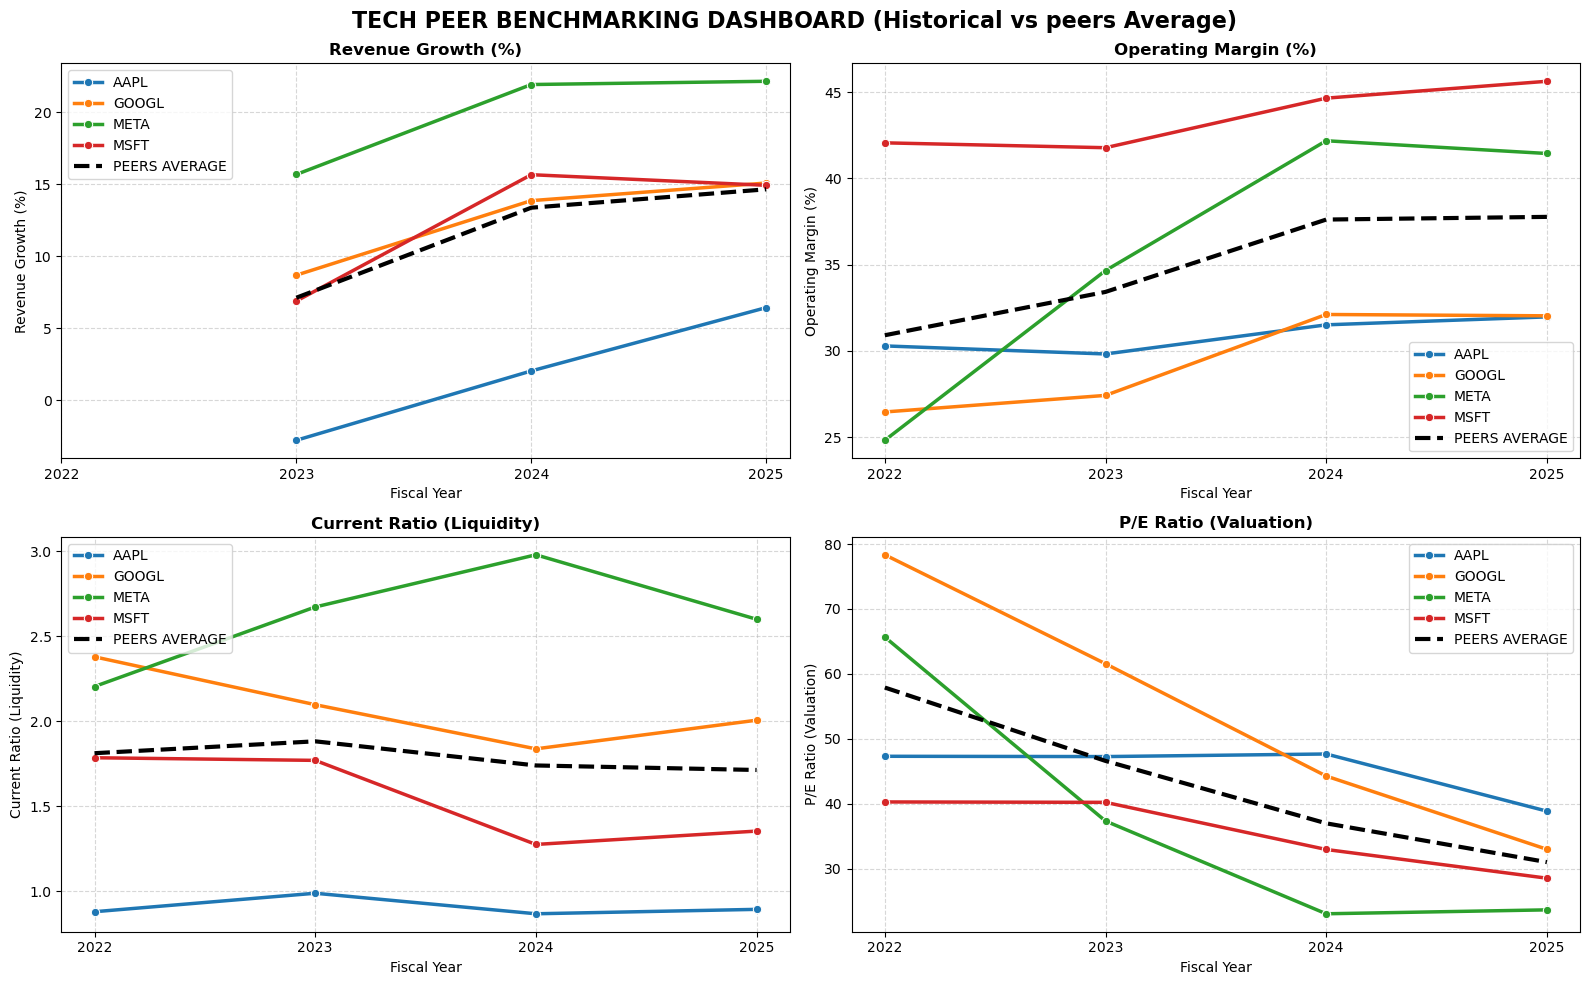

Dashboard rendered successfully!


In [91]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print(" Rendering Financial Peer Dashboard...")

#  Separate the real companies from the peers average row for clean plotting
companies_data = final_benchmark_table[final_benchmark_table["Company"] != "PEER_AVG"]
peers_avg_data = final_benchmark_table[final_benchmark_table["Company"] == "PEER_AVG"]

# Set up a professional 2x2 grid of subplots, Matplotlib creates an internal 2D array (a grid table) of plot windows
# thus the axes configuration down below to include the four variables
# plt.subplots handles the layout grid. figsize is (width, height) in inches.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("TECH PEER BENCHMARKING DASHBOARD (Historical vs peers Average)", fontsize=16, fontweight="bold")

# Create a configuration list mapping our columns to chart titles and grid positions 
# the variable 'metrics' will choose a column to represent, then give the graph a title based on this name, then choose the grid emplacement to plot it
metrics = [
    {"col": "Revenue_Growth_Pct", "title": "Revenue Growth (%)", "ax": axes[0, 0]},
    {"col": "Operating_Margin_Pct", "title": "Operating Margin (%)", "ax": axes[0, 1]},
    {"col": "Current_Ratio", "title": "Current Ratio (Liquidity)", "ax": axes[1, 0]},
    {"col": "PE_Ratio", "title": "P/E Ratio (Valuation)", "ax": axes[1, 1]}
]

# Loop through our metrics list and draw the charts dynamically
for m in metrics:
    # A. Plot the individual companies as solid lines with circular markers ('o')
    sns.lineplot(
        data=companies_data, x="Year", y=m["col"], hue="Company", 
        marker="o", linewidth=2.5, ax=m["ax"]
    )
    
    # B. Plot our Sample Average as a thick, dashed black line for a clear benchmark reference
    sns.lineplot(
        data=peers_avg_data, x="Year", y=m["col"], color="black", 
        linestyle="--", linewidth=3, label="PEERS AVERAGE", ax=m["ax"]
    )
    
    # C. Apply professional clean styling to each individual subplot
    m["ax"].set_title(m["title"], fontsize=12, fontweight="bold")
    m["ax"].set_ylabel(m["title"])
    m["ax"].set_xlabel("Fiscal Year")
    m["ax"].grid(True, linestyle="--", alpha=0.5)
    
    # Force years to display cleanly as integers (e.g., 2024) instead of floats (2024.0)
    years = sorted(final_benchmark_table["Year"].unique())
    m["ax"].set_xticks(years)
    m["ax"].set_xticklabels([str(int(y)) for y in years])

# 5. Clean up the padding between charts so nothing overlaps
plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "financial_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

print("Dashboard rendered successfully!")

In [43]:
import fpdf
from fpdf.enums import XPos, YPos

class FinancialReport(fpdf.FPDF) :
    def header(self) : #to call the function at each new page
        self.set_font('Helvetica","B",18)
        self.set_text_color(30,34,175)
        self.cell(0,12,"Financial Peer Benchmark Report",align="C") #cell containing the title aligned in the center
    def footer(self):
            self.set_y(-15)
            self.cell(0,10,f"Page {self.page_no()}/{{nb}}",align="C")

try:

    print("Beginning PDF creation...")

    pdf = FinancialReport()

    pdf.alias_nb_pages()

    pdf.add_page() #to start with the header
    pdf.multi_cell(0,6,f"this report present the benchmarking of the four tech companies :{company_tickers

SyntaxError: unterminated string literal (detected at line 6) (3573909091.py, line 6)

In [92]:
import fpdf
from fpdf.enums import XPos, YPos

class FinancialReport(fpdf.FPDF): #creation of our own version of the class fpdf

    def header(self):
        self.set_font("Helvetica", "B", 18)
        self.set_text_color(30, 64, 175)
        self.cell(0,12,"Financial Peer Benchmark Report",new_x=XPos.LMARGIN,new_y=YPos.NEXT,align="C") #a cell which display the title
        self.ln(5)

    def footer(self):
        self.set_y(-15)
        self.set_font("Helvetica", "I", 8)
        self.cell(0,10,f"Page {self.page_no()}/{{nb}}",align="C")

try:

    print("Beginning PDF creation...")

    pdf = FinancialReport()

    pdf.alias_nb_pages() #to count the number of pages

    pdf.add_page() #starts with header

    # INTRODUCTION

    pdf.set_font("Helvetica", "", 11)

    intro = ("This report presents a peer benchmarking analysis "
        "of Microsoft, Apple, Alphabet and Meta. "
        "Financial ratios have been computed from annual "
        "financial statements retrieved via Yahoo Finance "
        "and analyzed using Python.")

    pdf.multi_cell(0, 6, intro) #the text of introduction takes numerous cells

    pdf.ln(5) #Line break

    # COMPANIES ANALYZED

    pdf.set_font("Helvetica", "B", 13)

    pdf.cell(0,10,"1. Companies Analyzed",new_x=XPos.LMARGIN,new_y=YPos.NEXT)

    pdf.set_font("Helvetica", "", 11)

    for ticker in company_tickers:

        pdf.cell(0,7,f"- {ticker}",new_x=XPos.LMARGIN,new_y=YPos.NEXT)

    # PAGE 2

    pdf.add_page()

    pdf.set_font("Helvetica", "B", 13)

    pdf.cell(0,10,"2. Key Financial Ratios",new_x=XPos.LMARGIN,new_y=YPos.NEXT)

    pdf.ln(3)

    pdf.set_font("Helvetica", "B", 8)

    headers = ["Company","Year","Revenue Growth","Op Margin","Current Ratio","PE"]

    widths = [25, 15, 35, 35, 30, 25]

    for h, w in zip(headers, widths):
        pdf.cell(w, 8, h, border=1)

    pdf.ln()

    pdf.set_font("Helvetica", "", 8)
# The loop 'for _, row in final_benchmark_table.iterrows():' processes the 
# Pandas DataFrame row-by-row like a conveyor belt. 
#
# At each iteration, specific metrics (like 'Revenue_Growth_Pct') are extracted 
# into temporary variables (e.g., 'growth') to serve two critical purposes:
#
# 1. ANTI-CRASH PROTECTION ('pd.isna'): Financial data sometimes contains empty 
#    cells (NaN). FPDF will crash if it tries to print a NaN value. Storing the 
#    data first allows us to check if the cell is empty; if it is, we cleanly 
#    print 'N/A' instead of crashing the pipeline.
#
# 2. PROFESSIONAL FORMATTING ('.2f'): Raw numbers from Python often contain 
#    too many decimal places (e.g., 14.285714...). The variable allows us to 
#    apply an f-string format ('{growth:.2f}') to restrict the display to 
#    exactly two clean decimal places (e.g., 14.29) for a corporate look.
#
# Note on 'int(row["Year"])': Years are cast to integers first to strip away 
# any trailing decimals (converting '2022.0' to '2022') before being converted 
# to a string ('str') for FPDF compatibility.

    for _, row in final_benchmark_table.iterrows(): #takes one row at a time

        pdf.cell(widths[0], 8, str(row["Company"]), border=1)

        pdf.cell(widths[1], 8, str(int(row["Year"])), border=1)

        growth = row["Revenue_Growth_Pct"]

        pdf.cell(widths[2],8,"N/A" if pd.isna(growth) else f"{growth:.2f}",border=1)

        margin = row["Operating_Margin_Pct"]

        pdf.cell( widths[3],8,"N/A" if pd.isna(margin) else f"{margin:.2f}",border=1)

        current_ratio = row["Current_Ratio"]

        pdf.cell(widths[4],8,"N/A" if pd.isna(current_ratio) else f"{current_ratio:.2f}", border=1)

        pe = row["PE_Ratio"]

        pdf.cell(widths[5],8,"N/A" if pd.isna(pe) else f"{pe:.2f}",border=1)

        pdf.ln()

    # PAGE 3 DASHBOARD

    pdf.add_page()

    pdf.set_font("Helvetica", "B", 13)

    pdf.cell(0,10,"3. Financial Dashboard",new_x=XPos.LMARGIN,new_y=YPos.NEXT)

    pdf.image("financial_dashboard.png",x=10,y=35, w=190)

    # PAGE 4 CONCLUSION

    pdf.add_page()

    pdf.set_font("Helvetica", "B", 13)

    pdf.cell(0,10,"4. Key Findings",new_x=XPos.LMARGIN,new_y=YPos.NEXT)

    pdf.set_font("Helvetica", "", 11)

    pdf.multi_cell(0,7,
        (
            "- Revenue growth was benchmarked against the peer average.\n"
            "- Operating margin highlights profitability differences.\n"
            "- Current ratio measures liquidity strength.\n"
            "- PE ratio compares market valuation levels.\n"
            "- The analysis was fully automated using Python."
        )
    )

    pdf.output("Financial_Benchmark_Report.pdf") #the conclusion text

    print("PDF successfully generated")
    print("Financial_Benchmark_Report.pdf")

except Exception as e:

    print(f"ERROR: {e}")

Beginning PDF creation...
PDF successfully generated
Financial_Benchmark_Report.pdf
